# 20250912AS7341calibration

MBE: 1.0729, MAPE: 3.58% for mEDI comparison with nsp32 reference


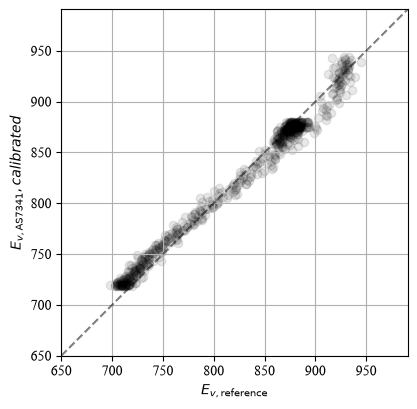

In [ ]:
'''
instructions:
- header for nsp32 should be timestamp_iso,timestamp_unix,340,345,350,355,360,365,370,375,
380,385,390,395,400,405,410,415,420,425,430,435,440,445,450,455,460,465,470,475,480,485,490,
495,500,505,510,515,520,525,530,535,540,545,550,555,560,565,570,575,580,585,590,595,600,605,
610,615,620,625,630,635,640,645,650,655,660,665,670,675,680,685,690,695,700,705,710,715,720,
725,730,735,740,745,750,755,760,765,770,775,780,785,790,795,800,805,810,815,820,825,830,835,
840,845,850,855,860,865,870,875,880,885,890,895,900,905,910,915,920,925,930,935,940,945,950
,955,960,965,970,975,980,985,990,995,1000,1005,1010
    # AS7341: https://cdn.sparkfun.com/assets/0/8/e/2/3/AS7341_DS000504_3-00.pdf#page=8.10
    # AS7341 output is The ADC is 16-bit. (0 to 65535) --> needs calibration.
    # NSP32 --> individually calibrated according to http://165.227.7.198/Resource/Data%20Sheet_NSP32_20170218_12.pdf
'''

import sys
sys.path.append('./src')
from src_ import as7341_calibrator
as7341_csv =     r"./20250912AS7341calibration/as7341_log.csv"
KM_CL_500A_csv = r"./20250912AS7341calibration/KM_CL_500A_log.csv"
nsp32_csv =      r"./20250912AS7341calibration/nsp32_log.csv"

calibrator = as7341_calibrator(as7341_csv=as7341_csv,
                               nsp32_csv=nsp32_csv,
                               KM_CL_500A_csv=KM_CL_500A_csv,
                               plot_scatter=1,
                               reference = "nsp32",
                               verbose=0)
# connection aborted "MBE: -3.5021, MAPE: 1.76% for mEDI comparison with km reference"
# MBE: 1.0729, MAPE: 3.58% for mEDI comparison with nsp32 reference


In [19]:
import pandas as pd
import numpy as np
out = calibrator.out.copy()
if len(calibrator.nsp32_collapsed) != len(out):
    shorter_df = calibrator.nsp32_collapsed if len(calibrator.nsp32_collapsed) < len(out) else out
    longer_df  = out if len(calibrator.nsp32_collapsed) < len(out) else calibrator.nsp32_collapsed
    print(shorter_df.head(3)), print(longer_df.head(3))


                timestamp_iso  timestamp_unix  415nm_f1  445nm_f2  480nm_f3  \
0  2025-12-09T11:50:19.053367    1.765281e+09  0.010101  0.013205  0.015498   
1  2025-12-09T11:50:20.720044    1.765281e+09  0.009848  0.012895  0.015307   
2  2025-12-09T11:50:22.387774    1.765281e+09  0.009534  0.013341  0.015362   

   515nm_f4  555nm_f5  590nm_f6  630nm_f7  680nm_f8  
0  0.015142  0.014459  0.011659  0.011078  0.008629  
1  0.015333  0.014527  0.012003  0.010729  0.008794  
2  0.015180  0.014124  0.012364  0.010657  0.008654  
             Date Time  415nm_f1  445nm_f2  480nm_f3  515nm_f4  555nm_f5  \
0  12/09/2025 12:51:01  0.008138  0.010873  0.012716  0.012711  0.012277   
1  12/09/2025 12:51:02  0.008146  0.010879  0.012721  0.012712  0.012276   
2  12/09/2025 12:51:03  0.008140  0.010875  0.012713  0.012707  0.012273   

   590nm_f6  630nm_f7  680nm_f8          Ev        timestamp_iso  
0  0.010953  0.009841  0.007734  861.945373  2025-12-09T12:51:01  
1  0.010950  0.009831  0.007

In [25]:
longer_df

,Date Time,415nm_f1,445nm_f2,480nm_f3,515nm_f4,555nm_f5,590nm_f6,630nm_f7,680nm_f8,Ev,timestamp_iso
0,12/09/2025 12:51:01,0.008138,0.010873,0.012716,0.012711,0.012277,0.010953,0.009841,0.007734,861.945373,2025-12-09 12:51:01
1,12/09/2025 12:51:02,0.008146,0.010879,0.012721,0.012712,0.012276,0.010950,0.009831,0.007737,861.792236,2025-12-09 12:51:02
2,12/09/2025 12:51:03,0.008140,0.010875,0.012713,0.012707,0.012273,0.010946,0.009833,0.007733,861.488709,2025-12-09 12:51:03
3,12/09/2025 12:51:04,0.008148,0.010880,0.012725,0.012707,0.012276,0.010955,0.009827,0.007728,861.777649,2025-12-09 12:51:04
4,12/09/2025 12:51:05,0.008143,0.010876,0.012717,0.012709,0.012280,0.010958,0.009839,0.007743,862.007812,2025-12-09 12:51:05
...,...,...,...,...,...,...,...,...,...,...,...
976,12/09/2025 13:07:17,0.008682,0.011591,0.013583,0.013593,0.013139,0.011730,0.010542,0.008334,922.348816,2025-12-09 13:07:17
977,12/09/2025 13:07:18,0.008682,0.011591,0.013583,0.013593,0.013139,0.011730,0.010542,0.008334,922.348816,2025-12-09 13:07:18
978,12/09/2025 13:07:19,0.008682,0.011591,0.013583,0.013593,0.013139,0.011730,0.010542,0.008334,922.348816,2025-12-09 13:07:19
979,12/09/2025 13:07:20,0.008682,0.011591,0.013583,0.013593,0.013139,0.011730,0.010542,0.008334,922.348816,2025-12-09 13:07:20


# Visualizers

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import tab10
import sys
sys.path.append('./src')
from src_ import *

class analyzer():
    
    
        
# ---------------- NSP32 wavelengths from df1 ----------------

wl_cols = [c for c in analyzer.df1.columns if c not in ["timestamp_iso", "timestamp_unix"]]
wl_vals = np.array([int(c) for c in wl_cols])

# ---------------- KM_CL_500A wavelengths ----------------
# 360-780 nm with 1 nm step
km_wl_vals = np.arange(360, 781, 1)

# ---------------- PLOT ----------------
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# --- Top: AS7341 bands ---
as_colors = tab10(np.linspace(0, 1, len(AS7341_CHANNELS)))

for (name, (lo, hi)), color in zip(BAND_RANGES.items(), as_colors):
    center = (lo + hi) / 2
    ax1.axvspan(lo, hi, color=color, alpha=0.3)
    ax1.axvline(center, color=color, linestyle="--", linewidth=1)
    ax1.text(center, 0.5, name, rotation=90, ha="center", va="center",
             fontsize=8, color=color)

ax1.set_ylim(0, 1)
ax1.set_yticks([])
ax1.set_title("AS7341")

# --- Middle: NSP32 wavelengths ---
for wl in wl_vals:
    ax2.axvline(wl, alpha=0.4)

ax2.text(wl_vals[0], 0.8, f"{wl_vals[0]} nm", ha="left", va="center", fontsize=8)
ax2.text(wl_vals[-1], 0.8, f"{wl_vals[-1]} nm", ha="right", va="center", fontsize=8)

ax2.set_ylim(0, 1)
ax2.set_yticks([])
ax2.set_title("NSP32")

# --- Bottom: KM_CL_500A wavelengths ---
for wl in km_wl_vals:
    ax3.axvline(wl, alpha=0.2, linewidth=2)

ax3.text(km_wl_vals[0], 0.8, f"{km_wl_vals[0]} nm", ha="left", va="center", fontsize=8)
ax3.text(km_wl_vals[-1], 0.8, f"{km_wl_vals[-1]} nm", ha="right", va="center", fontsize=8)

ax3.set_ylim(0, 1)
ax3.set_yticks([])
ax3.set_xlabel("Wavelength (nm)")
ax3.set_title("KM_CL_500A")


plt.tight_layout()
plt.savefig("wavelengths_coverages.pgf", format='pgf', bbox_inches='tight')

plt.show()


NameError: name 'analyzer' is not defined

# Colour differences

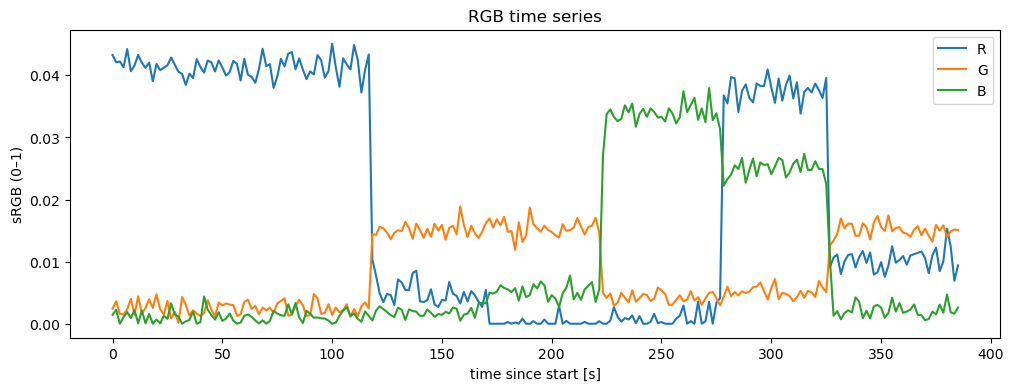

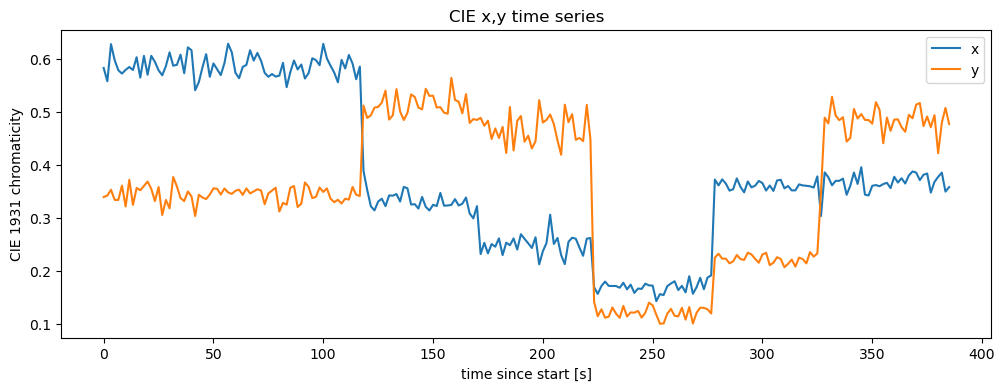

In [ ]:
import sys
sys.path.append('./src')
from src_ import *


"""
KM data is flat! 
"""

km_colour = r"./20250912colourmatching/KM_CL_500A.csv"
nsp_colour = r"./20250912colourmatching/nsp32_log.csv"
as7341_colour = r"./20250912colourmatching/as7341_log.csv"

calibrator = as7341_calibrator(as7341_csv=as7341_colour,
                               nsp32_csv=nsp_colour,
                               KM_CL_500A_csv=km_colour
                               )

df = calibrator.nsp32_collapsed.copy()
# df = calibrator.KM_CL_500A_collapsed.copy()
plot_colour_time_series(df)

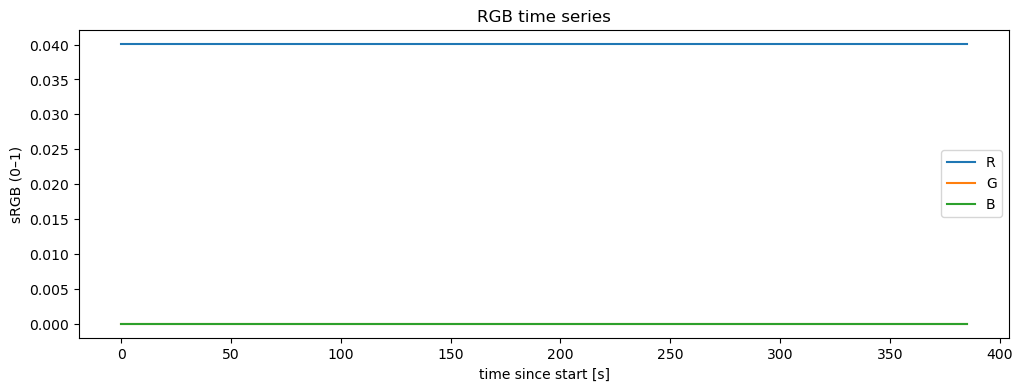

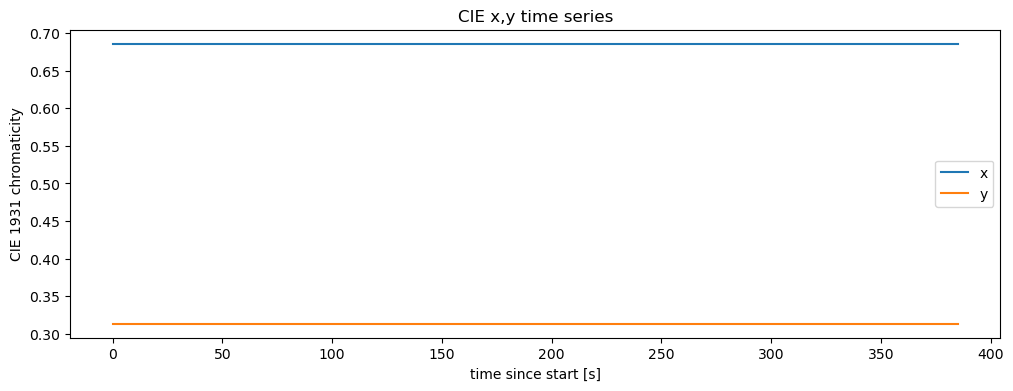

In [ ]:
df = calibrator.KM_CL_500A_collapsed.copy()
plot_colour_time_series(df)

# Cosine response

In [ ]:
'''
- collapse each
- plot the timeseries illuminance values for each
'''
as7341_cosine =    r"./20250912cosine/as7341_log.csv"
nsp32_cosine =      r"./20250912cosine/nsp32_log.csv"
KM_CL_500A_cosine = r"./20250912cosine/KM_CL_500A_log.csv"

# collapsed 
import sys
sys.path.append('./src')
from src_ import *
calibrator = as7341_calibrator(as7341_csv=as7341_cosine,
                               nsp32_csv=nsp32_cosine,
                               KM_CL_500A_csv=KM_CL_500A_cosine
                               )

In [ ]:
# nsp32
times, illuminances = [], []
for ts in calibrator.nsp32_collapsed.index:
    as_ = apply_action_spectra(
        calibrator.nsp32.loc[ts, '340':'1010'].values,
        wavelengths=list(range(340, 1011, 5))
    )
    times.append(ts), illuminances.append(as_.photopic)


In [ ]:
# cl500a
times_cl, illuminances_cl = [], []
for ts in calibrator.KM_CL_500A.index:
    as_ = apply_action_spectra(
        calibrator.KM_CL_500A.loc[ts, 360:780].values,
        wavelengths=list(range(360, 781, 1))
    )
    times_cl.append(ts), illuminances_cl.append(as_.photopic)

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(times, (1/np.cos(np.radians(55)))*illuminances,  linestyle="-")
plt.xlabel("Timestep")
plt.ylabel("$E_{v}$")
plt.title(r"NSP32m")
plt.grid(True)
# set the y limits 0-350
plt.ylim(0, 350)
plt.xlim(0, len(times)-1)
plt.tight_layout()
plt.show()

TypeError: can't multiply sequence by non-int of type 'numpy.float64'

<Figure size 800x400 with 0 Axes>

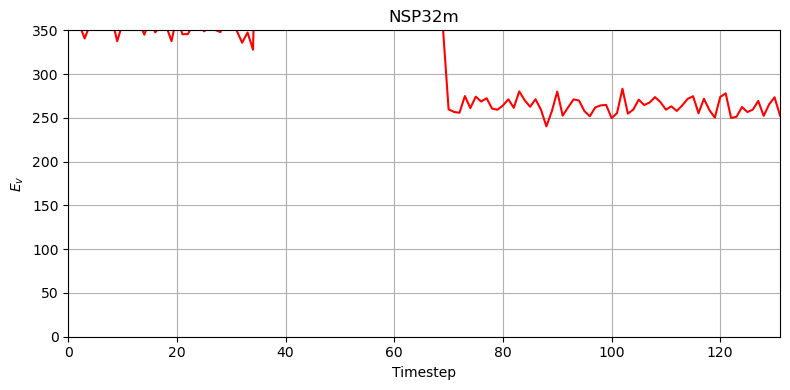

In [ ]:

plt.figure(figsize=(8, 4))
plt.plot(times, list((1/np.cos(np.radians(60)))*np.array(illuminances)),  linestyle="-", color='red')
plt.xlabel("Timestep")
plt.ylabel("$E_{v}$")
plt.title(r"NSP32m")
plt.grid(True)
# set the y limits 0-350
plt.ylim(0, 350)
plt.xlim(0, len(times)-1)
plt.tight_layout()
plt.show()

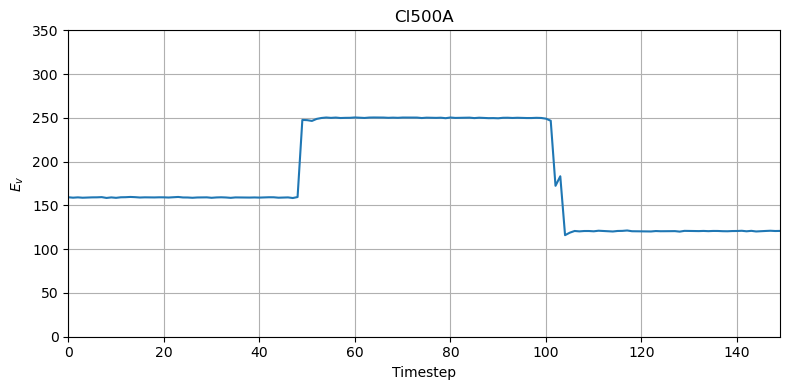

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(times_cl, illuminances_cl,  linestyle="-")
plt.xlabel("Timestep")
plt.ylabel("$E_{v}$")
plt.title(r"Cl500A")
plt.grid(True)
# set the y limits 0-350
plt.ylim(0, 350)
plt.xlim(0, len(times_cl)-1)
plt.tight_layout()
plt.show()


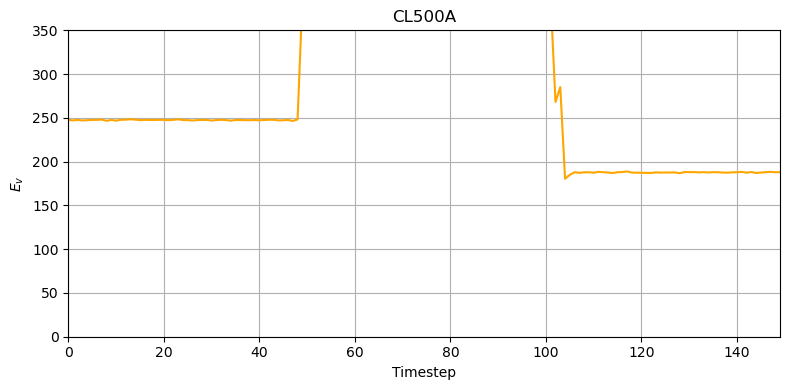

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(times_cl, list((1/np.cos(np.radians(50)))*np.array(illuminances_cl)),  linestyle="-", color='orange')
plt.xlabel("Timestep")
plt.ylabel("$E_{v}$")
plt.title(r"CL500A")
plt.grid(True)
# set the y limits 0-350
plt.ylim(0, 350)
plt.xlim(0, len(times_cl)-1)
plt.tight_layout()
plt.show()

1.5625